### Libraries

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup

In [2]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) # Set the seed for the current GPU
    torch.cuda.manual_seed_all(seed) # Set the seed for all GPUs (if you are using multi-GPU).
    
# Set deterministic behavior for CUDA operations
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set up Hugging Face cache directory
cache_path = "../huggingface_cache"
cache_dir = Path(cache_path)
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


In [4]:
# Set path for data
data_path = "../modeldata"

Choose between 2 different sets of data with different ratios

In [ ]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train70.csv")
val_df = pd.read_csv(f"{data_path}/val15.csv")
test_df = pd.read_csv(f"{data_path}/test15.csv")

ratio = "70:15:15"

In [6]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv(f"{data_path}/train80.csv")
val_df = pd.read_csv(f"{data_path}/val10.csv")
test_df = pd.read_csv(f"{data_path}/test10.csv")

ratio = "80:10:10"

In [7]:
# Ratio used
print(f"Data split ratio: {ratio}")

Data split ratio: 80:10:10


Once a set has been chosen, continue with next steps

In [8]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [9]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (18302, 2) {0: 9151, 1: 9151}
val: (2288, 2) {0: 1144, 1: 1144}
test: (2288, 2) {0: 1144, 1: 1144}


In [10]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (657 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 216322), ('i', 54906), ('you', 40629), ('the', 31056), ('to', 24273), ('it', 20227), ('a', 19852), ('me', 18337), ('and', 17799), ('not', 15771)]


In [11]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 61
sample ids: [2026, 1010, 2026, 1010, 2092, 1010, 2009, 2003, 25085, 2066, 2057, 2024, 2035, 2183, 2000, 3280, 1010, 2035, 2183, 2000]


In [12]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label

### Hyperparameter Tuning with Optuna

We'll search for the best hyperparameters using Optuna, which efficiently explores different combinations and focuses on promising regions. We'll tune:
- Learning rate (1e-4 to 1e-3)
- Embedding dimension (64, 128, 256)
- Hidden dimension (128, 256, 512)
- Number of layers (1, 2, 3)
- Dropout rate (0.1 to 0.5)
- Batch size (16, 32, 64)

In [13]:
# Define the LSTM model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 2,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)

In [14]:
# Run one epoch of training or evaluation
def run_epoch(model, loader: DataLoader, criterion, optimizer=None, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())
        
        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions

In [15]:
# Create a seeded generator for the DataLoader
g = torch.Generator()
g.manual_seed(42)

In [ ]:
import optuna
from optuna.pruners import MedianPruner

def objective(trial: optuna.Trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 5e-4, 1e-3])
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.3, 0.5])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Create data loaders with the suggested batch size
    # train_loader = DataLoader(LyricsDataset(train_df), batch_size=batch_size, shuffle=True)
    train_loader = DataLoader(
        LyricsDataset(train_df), 
        batch_size=batch_size, 
        shuffle=True,
        generator=g,           
        num_workers=0          # for reproducibility
    )
    val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False, num_workers=0)

    # Initialize model with suggested hyperparameters
    model = LSTMClassifier(
        vocab_size=len(tokenizer),
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train for a few epochs with Early Stopping
    num_epochs = 10
    best_val_loss = float("inf")
    patience = 3
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss, val_acc, _, _, _ = run_epoch(model, val_loader, criterion, training=False)

        print(f"  Trial {trial.number}, Epoch {epoch + 1}/{num_epochs}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        # Early Stopping Logic (Patience = 3)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter when loss improves
        else:
            patience_counter += 1  # Increment patience counter when loss doesn't improve

        # Prune trial if validation loss is not improving (MedianPruner)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stop if patience is exceeded
        if patience_counter >= patience:
            print(f"  Early stopping triggered! No improvement for {patience} epochs.")
            break

    return best_val_loss

In [17]:
# For reproducibility, set a fixed seed for the TPE sampler
sampler = optuna.samplers.TPESampler(seed=42)

In [18]:
# Create a study and run the hyperparameter search
study = optuna.create_study(
    direction="minimize",  # Minimize validation loss
    sampler=sampler,
    pruner=MedianPruner(),
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-08-07 11:55:46,498] A new study created in memory with name: no-name-7fc6c746-450e-45fc-a29f-2cf91e91d76a
  0%|          | 0/20 [00:00<?, ?it/s]

  Trial 0, Epoch 1/10: val_loss=0.6004, val_acc=0.6901
  Trial 0, Epoch 2/10: val_loss=0.5802, val_acc=0.6888
  Trial 0, Epoch 3/10: val_loss=0.5040, val_acc=0.7474
  Trial 0, Epoch 4/10: val_loss=0.4502, val_acc=0.7872
  Trial 0, Epoch 5/10: val_loss=0.4443, val_acc=0.7976
  Trial 0, Epoch 6/10: val_loss=0.4088, val_acc=0.8099
  Trial 0, Epoch 7/10: val_loss=0.4056, val_acc=0.8103
  Trial 0, Epoch 8/10: val_loss=0.4112, val_acc=0.8278
  Trial 0, Epoch 9/10: val_loss=0.4220, val_acc=0.8260


Best trial: 0. Best value: 0.40557:   5%|▌         | 1/20 [14:43<4:39:48, 883.58s/it]

  Trial 0, Epoch 10/10: val_loss=0.4518, val_acc=0.8274
  Early stopping triggered! No improvement for 3 epochs.
[I 2026-08-07 12:10:30,081] Trial 0 finished with value: 0.4055702166332232 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'batch_size': 16}. Best is trial 0 with value: 0.4055702166332232.
  Trial 1, Epoch 1/10: val_loss=0.6127, val_acc=0.6460
  Trial 1, Epoch 2/10: val_loss=0.6173, val_acc=0.6573
  Trial 1, Epoch 3/10: val_loss=0.5576, val_acc=0.7102
  Trial 1, Epoch 4/10: val_loss=0.4822, val_acc=0.7666
  Trial 1, Epoch 5/10: val_loss=0.4331, val_acc=0.8011
  Trial 1, Epoch 6/10: val_loss=0.4172, val_acc=0.8177
  Trial 1, Epoch 7/10: val_loss=0.4091, val_acc=0.8191
  Trial 1, Epoch 8/10: val_loss=0.4409, val_acc=0.8234
  Trial 1, Epoch 9/10: val_loss=0.4164, val_acc=0.8191


Best trial: 0. Best value: 0.40557:  10%|█         | 2/20 [29:26<4:24:52, 882.92s/it]

...

  Trial 17, Epoch 1/10: val_loss=0.6079, val_acc=0.6486
[I 2026-08-07 13:11:20,292] Trial 17 pruned. 


Best trial: 4. Best value: 0.386417:  95%|█████████▌| 19/20 [1:16:13<01:36, 96.64s/it] 

  Trial 18, Epoch 1/10: val_loss=0.5989, val_acc=0.7146
[I 2026-08-07 13:12:00,217] Trial 18 pruned. 


Best trial: 4. Best value: 0.386417: 100%|██████████| 20/20 [1:17:17<00:00, 231.86s/it]

  Trial 19, Epoch 1/10: val_loss=0.6090, val_acc=0.6525
[I 2026-08-07 13:13:03,635] Trial 19 pruned. 


In [29]:
# Print best trial results
best_trial = study.best_trial

print(f"Best validation loss: {best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best validation loss: 0.3864
Best hyperparameters:
  learning_rate: 0.0005
  embedding_dim: 256
  hidden_dim: 128
  num_layers: 3
  dropout: 0.5
  batch_size: 32


In [ ]:
# Reset seeds before final model creation
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
random.seed(42)
np.random.seed(42)

# Create fresh generator
g_final = torch.Generator() # Use g_final in DataLoaders instead of g
g_final.manual_seed(42)

### Final Training with Best Hyperparameters

Train the final model using the best hyperparameters found by Optuna on the full train set, and evaluate on the test set.

In [ ]:
# Extract best hyperparameters
best_params = best_trial.params
best_learning_rate = best_params["learning_rate"]
best_embedding_dim = best_params["embedding_dim"]
best_hidden_dim = best_params["hidden_dim"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_batch_size = best_params["batch_size"]

# Create data loaders with best batch size
train_loader = DataLoader(LyricsDataset(train_df), batch_size=best_batch_size, shuffle=True, generator=g_final, num_workers=0)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=best_batch_size, shuffle=False, generator=g_final, num_workers=0)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=best_batch_size, shuffle=False, generator=g_final, num_workers=0)

# Initialize final model with best hyperparameters
model = LSTMClassifier(
    vocab_size=len(tokenizer),
    embedding_dim=best_embedding_dim,
    hidden_dim=best_hidden_dim,
    num_layers=best_num_layers,
    dropout=best_dropout,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_learning_rate)

print("Final model architecture:")
print(model)

Final model architecture:
LSTMClassifier(
  (embedding): Embedding(30522, 256, padding_idx=0)
  (lstm): LSTM(256, 128, num_layers=3, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [ ]:
# Train the final model with best hyperparameters

num_epochs = 10
best_val_loss = float("inf")
best_model_path = Path("lstm_lyrics_classifier.pt")
history = []

# Add patience variables for early stopping
patience = 3
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_targets, train_probs, train_predictions = run_epoch(model, train_loader, criterion, optimizer, training=True)
    val_loss, val_acc, val_targets, val_probs, val_predictions = run_epoch(model, val_loader, criterion, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    # Check if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0  # Reset patience counter when loss improves
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1  # Increment patience counter when loss doesn't improve
    
    # Early stopping logic - break if patience is exceeded
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered! No improvement for {patience} consecutive epochs.")
        print(f"Best validation loss: {best_val_loss:.4f}")
        break
    
history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6210 train_acc=0.6487 | val_loss=0.5443 val_acc=0.7251
Epoch 02 | train_loss=0.5363 train_acc=0.7459 | val_loss=0.5325 val_acc=0.7395
Epoch 03 | train_loss=0.4781 train_acc=0.7741 | val_loss=0.4901 val_acc=0.7351
Epoch 04 | train_loss=0.4239 train_acc=0.8050 | val_loss=0.4390 val_acc=0.7981
Epoch 05 | train_loss=0.3737 train_acc=0.8401 | val_loss=0.4489 val_acc=0.7968
Epoch 06 | train_loss=0.3400 train_acc=0.8590 | val_loss=0.4384 val_acc=0.8177
Epoch 07 | train_loss=0.2937 train_acc=0.8817 | val_loss=0.4210 val_acc=0.8186
Epoch 08 | train_loss=0.2332 train_acc=0.9090 | val_loss=0.4362 val_acc=0.8221
Epoch 09 | train_loss=0.1903 train_acc=0.9284 | val_loss=0.4704 val_acc=0.8221
Epoch 10 | train_loss=0.1516 train_acc=0.9456 | val_loss=0.5150 val_acc=0.8252


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.620957,0.648672,0.544286,0.725087
1,2,0.536277,0.745875,0.532456,0.739510
2,3,0.478050,0.774123,0.490053,0.735140
3,4,0.423857,0.805049,0.438964,0.798077
4,5,0.373655,0.840127,0.448920,0.796766
5,6,0.339951,0.858977,0.438432,0.817745
6,7,0.293743,0.881652,0.420954,0.818619
7,8,0.233188,0.909026,0.436188,0.822115
8,9,0.190334,0.928368,0.470362,0.822115
9,10,0.151614,0.945634,0.515010,0.825175


### Model Evaluation

In [22]:
# Load best checkpoint and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(model, test_loader, criterion, training=False)

#### Classification Report

In [30]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"LSTM CLASSIFICATION REPORT (TUNING - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

LSTM CLASSIFICATION REPORT (TUNING - 80:10:10):
Accuracy: 0.8098776223776224
Precision: 0.8231540565177757
Recall: 0.7893356643356644
F1-score: 0.8058902275769746


#### ROC-AUC Curve

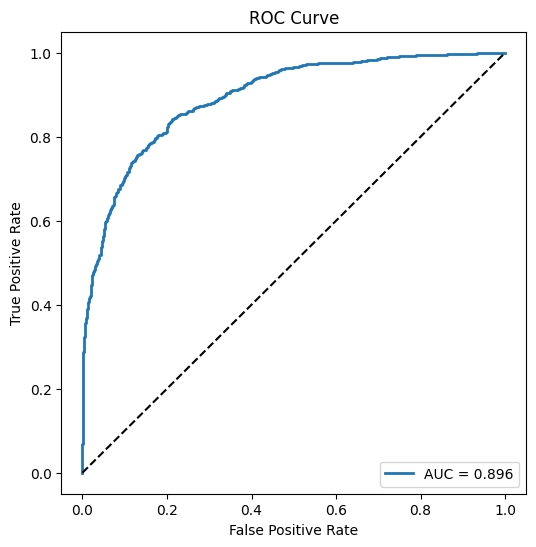

In [31]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9016260446894424


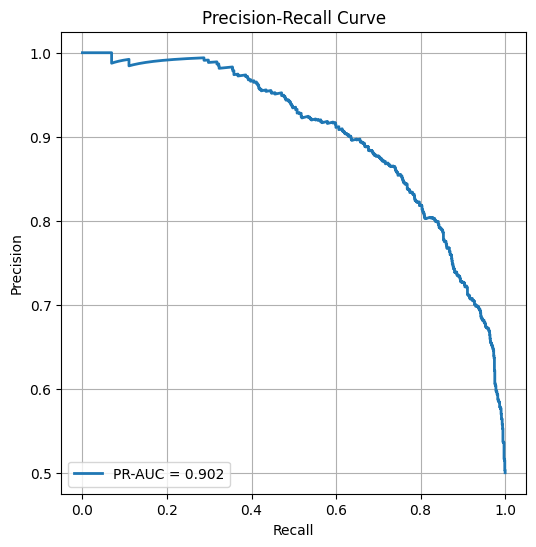

In [32]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

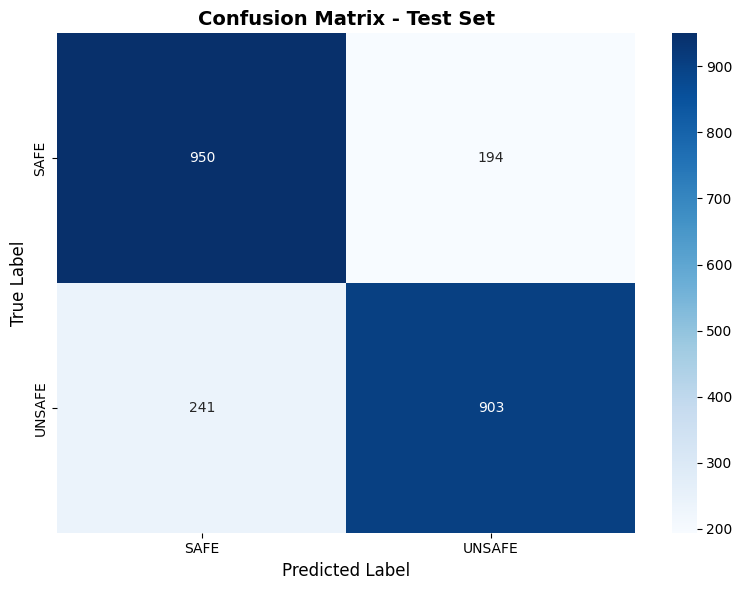

In [33]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [34]:
artifact_dir = Path("lstm_artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lyrics_lstm.pt"
vocab_path = artifact_dir / "lyrics_vocab.json"
params_path = artifact_dir / "best_hyperparams.json"

torch.save(model.state_dict(), model_path)
with open(vocab_path, "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, ensure_ascii=False, indent=2)
with open(params_path, "w", encoding="utf-8") as params_file:
    json.dump(best_params, params_file, indent=2)

print("Artifacts saved:")
print(f"  Model: {model_path}")
print(f"  Vocab: {vocab_path}")
print(f"  Best hyperparameters: {params_path}")

Artifacts saved:
  Model: lstm_artifacts\lyrics_lstm.pt
  Vocab: lstm_artifacts\lyrics_vocab.json
  Best hyperparameters: lstm_artifacts\best_hyperparams.json


In [28]:
def predict_text(text: str):
    model.eval()
    input_ids, length = numericalize(text)
    with torch.no_grad():
        logits = model(input_ids.unsqueeze(0).to(device), length.unsqueeze(0).to(device))
        probability = torch.sigmoid(logits).item()
        prediction = int(probability >= 0.5)
    return probability, prediction


sample_probability, sample_prediction = predict_text("you in the dark")
print({"probability": sample_probability, "prediction": sample_prediction})

{'probability': 0.33331573009490967, 'prediction': 0}
